# 5_pCMV_percenrage.py

In [2]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata as ad
import os
from collections import Counter
from sklearn.decomposition import PCA

#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


working_dic="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/scanpy_object/"
output_path="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/scanpy_object/"
os.chdir(output_path)


In [5]:
#read in qc filtered and doublet removed scanpy object
adata=sc.read("Humanxeno_annot.h5ad")
adata_raw=sc.read("Humanxeno_raw.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 20289 × 2000
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_hs_mt', 'log1p_total_counts_hs_mt', 'pct_counts_hs_mt', 'total_counts_hs_ribo', 'log1p_total_counts_hs_ribo', 'pct_counts_hs_ribo', 'total_counts_ss_mt', 'log1p_total_counts_ss_mt', 'pct_counts_ss_mt', 'total_counts_ss_ribo', 'log1p_total_counts_ss_ribo', 'pct_counts_ss_ribo', 'leiden_06', 'leiden_07', 'leiden_08', 'leiden_10', 'leiden_13', 'leiden_15', 'leiden_17', 'leiden_19', 'cell_type'

In [11]:
adata_raw.obs=adata.obs

In [12]:
# --- Step 1: Identify pCMV genes ---
# Create a boolean mask to find all genes starting with the specified prefix.
is_pcmv_gene = adata_raw.var_names.str.startswith('Sus_scrofa___exon-P379_gp')

# Optional: Print how many pCMV genes were found
print(f"Found {is_pcmv_gene.sum()} pCMV genes in adata_raw.var_names.")

# --- Step 2: Calculate pCMV metrics for each cell ---
# Create a view of the AnnData object containing only the pCMV genes.
adata_pcmv = adata_raw[:, is_pcmv_gene]

# Calculate the total UMI counts from pCMV genes for each cell (row).
# .sum(axis=1) sums across the genes for each cell.
# np.asarray(...).ravel() converts the matrix result to a flat array.
n_counts_pCMV = np.asarray(adata_pcmv.X.sum(axis=1)).ravel()

# Calculate the number of unique pCMV genes expressed in each cell.
# (adata_pcmv.X > 0) creates a boolean matrix of expressed genes.
# .sum(axis=1) then counts how many are True for each cell.
n_genes_pCMV = np.asarray((adata_pcmv.X > 0).sum(axis=1)).ravel()

# --- Step 3: Add metrics and apply the infection threshold ---
# Add the calculated metrics to the .obs dataframe.
adata_raw.obs['n_counts_pCMV'] = n_counts_pCMV
adata_raw.obs['n_genes_pCMV'] = n_genes_pCMV

# Define your infection threshold criteria.
# You can easily add more thresholds to this dictionary if needed.
pcmv_thresholds = {
    'is_infected_pCMV': {
        'n_counts_pCMV': 10,  # Minimum UMIs
        'n_genes_pCMV': 2,    # Minimum genes
        'description': 'Stringent: ≥10 UMIs + ≥2 genes'
    }
}

# Apply the threshold to create the final boolean column.
for col_name, criteria in pcmv_thresholds.items():
    infection_condition = (
        (adata_raw.obs['n_counts_pCMV'] >= criteria['n_counts_pCMV']) & 
        (adata_raw.obs['n_genes_pCMV'] >= criteria['n_genes_pCMV'])
    )
    # Add the final boolean column to adata_raw.obs
    adata_raw.obs[col_name] = infection_condition
    
    # --- Verification Step ---
    # Print a summary to verify the result.
    print(f"\nSuccessfully added '{col_name}' column to adata_raw.obs.")
    print(f"Criteria: {criteria['description']}")
    print("-----------------------------------------")
    print("Infection status counts:")
    print(adata_raw.obs[col_name].value_counts())
    print("-----------------------------------------")

Found 78 pCMV genes in adata_raw.var_names.

Successfully added 'is_infected_pCMV' column to adata_raw.obs.
Criteria: Stringent: ≥10 UMIs + ≥2 genes
-----------------------------------------
Infection status counts:
is_infected_pCMV
False    20265
True        24
Name: count, dtype: int64
-----------------------------------------


In [14]:
if 'is_infected_pCMV' in adata_raw.obs.columns and 'cell_type' in adata_raw.obs.columns:
    
    # Group by cell type and calculate the mean of the boolean 'is_infected_pCMV' column.
    # The mean of a boolean series is the proportion of True values.
    infection_percentage_by_cell_type = adata_raw.obs.groupby('cell_type')['is_infected_pCMV'].mean() * 100
    
    # Convert to a DataFrame for better printing and rename the column.
    percentage_df = infection_percentage_by_cell_type.reset_index()
    percentage_df.columns = ['Cell Type', 'Infection Percentage']
    
    # Sort the results for clarity
    percentage_df = percentage_df.sort_values(by='Infection Percentage', ascending=False)
    
    print("Percentage of pCMV-Infected Nuclei by Cell Type:")
    print("--------------------------------------------------")
    print(percentage_df.to_string(index=False))
    print("--------------------------------------------------")

else:
    print("Error: Required columns ('is_infected_pCMV' and/or 'cell_type') not found in adata_raw.obs.")
    print("Please make sure you have run the previous steps and specified the correct cell type column name.")


Percentage of pCMV-Infected Nuclei by Cell Type:
--------------------------------------------------
               Cell Type  Infection Percentage
                      EC              1.449275
                Pericyte              0.116414
             Fibroblasts              0.044316
Endocardial_Lymphatic_EC              0.000000
                      CM              0.000000
         Lymphoids_human              0.000000
               Lymphoids              0.000000
                Myeloids              0.000000
          Myeloids_human              0.000000
          Neuronal_cells              0.000000
                     SMC              0.000000
--------------------------------------------------


/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_43650/1949358663.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  infection_percentage_by_cell_type = adata_raw.obs.groupby('cell_type')['is_infected_pCMV'].mean() * 100


/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_43650/3702678727.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


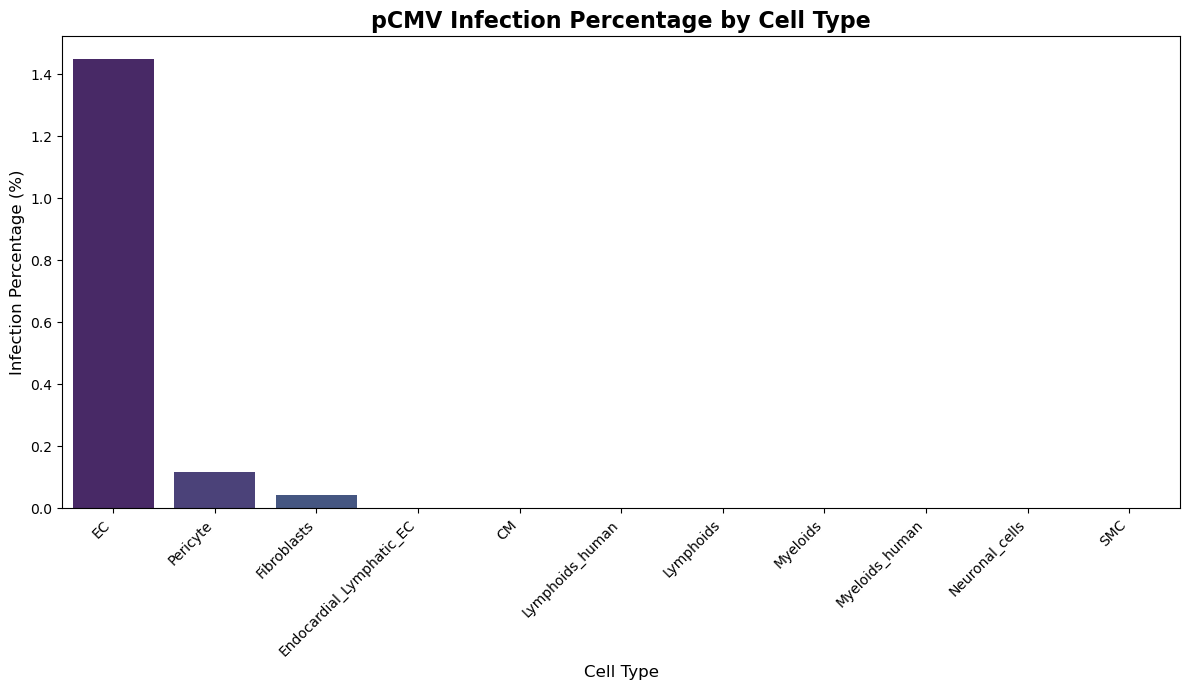

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Create or load your DataFrame ---
# This recreates the DataFrame based on your data.
# If your 'percentage_df' already exists in your environment, you can skip this part.
data = {
    'Cell Type': [
        'EC', 'Pericyte', 'Fibroblasts', 'Endocardial_Lymphatic_EC',
        'CM', 'Lymphoids_human', 'Lymphoids', 'Myeloids', 'Myeloids_human',
        'Neuronal_cells', 'SMC'
    ],
    'Infection Percentage': [
        1.449275, 0.116414, 0.044316, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    ]
}
percentage_df = pd.DataFrame(data)

# Optional: Sort the DataFrame to have the bars in descending order
percentage_df = percentage_df.sort_values(by='Infection Percentage', ascending=False)


# --- Step 2: Create the bar plot ---
# Set the figure size for better aesthetics
plt.figure(figsize=(12, 7))

# Generate the bar plot using seaborn
sns.barplot(
    x='Cell Type',
    y='Infection Percentage',
    data=percentage_df,
    palette='viridis'  # You can change the color palette (e.g., 'mako', 'rocket')
)


# --- Step 3: Customize the plot ---
# Add a title and labels for clarity
plt.title('pCMV Infection Percentage by Cell Type', fontsize=16, fontweight='bold')
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Infection Percentage (%)', fontsize=12)

# Rotate the x-axis labels to prevent them from overlapping
plt.xticks(rotation=45, ha='right')

# Use a tight layout to ensure all elements fit without being cut off
plt.tight_layout()


# --- Step 4: Display and save the plot ---
# Save the plot to a file. The dpi (dots per inch) increases resolution.
plt.savefig('infection_percentage_barplot.png', dpi=300)

# Display the plot
plt.show()


/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_43650/1755261752.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


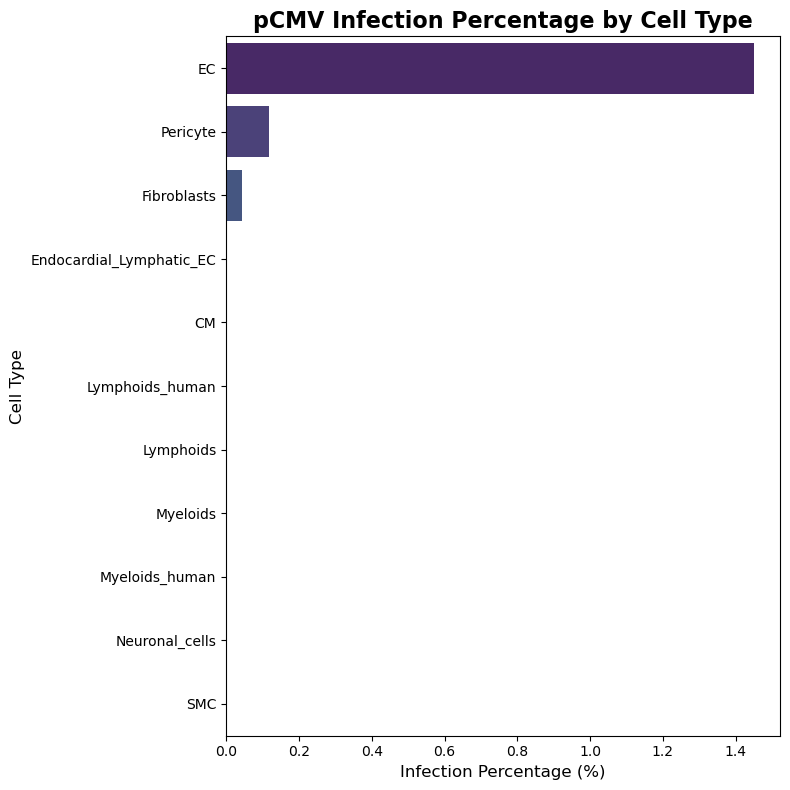

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Create or load your DataFrame ---
# This recreates the DataFrame based on your data.
# If your 'percentage_df' already exists in your environment, you can skip this part.
data = {
    'Cell Type': [
        'EC', 'Pericyte', 'Fibroblasts', 'Endocardial_Lymphatic_EC',
        'CM', 'Lymphoids_human', 'Lymphoids', 'Myeloids', 'Myeloids_human',
        'Neuronal_cells', 'SMC'
    ],
    'Infection Percentage': [
        1.449275, 0.116414, 0.044316, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    ]
}
percentage_df = pd.DataFrame(data)

# Optional: Sort the DataFrame to have the bars in descending order
# For a horizontal plot, this puts the highest value at the top.
percentage_df = percentage_df.sort_values(by='Infection Percentage', ascending=False)


# --- Step 2: Create the bar plot ---
# Set the figure size for better aesthetics (width has been reduced)
plt.figure(figsize=(8, 8))

# Generate the horizontal bar plot by swapping x and y axes
sns.barplot(
    x='Infection Percentage',
    y='Cell Type',
    data=percentage_df,
    palette='viridis'  # You can change the color palette (e.g., 'mako', 'rocket')
)


# --- Step 3: Customize the plot ---
# Add a title and labels for clarity
plt.title('pCMV Infection Percentage by Cell Type', fontsize=16, fontweight='bold')
plt.xlabel('Infection Percentage (%)', fontsize=12)
plt.ylabel('Cell Type', fontsize=12)

# Use a tight layout to ensure all elements fit without being cut off
plt.tight_layout()


# --- Step 4: Display and save the plot ---
# Save the plot to a file. The dpi (dots per inch) increases resolution.
plt.savefig('infection_percentage_barplot_horizontal.png', dpi=300)

# Display the plot
plt.show()

/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_52880/422344222.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_colors = cm.get_cmap("viridis")(np.linspace(0.2, 0.9, num_bars))
/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_52880/422344222.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_52880/422344222.py:38: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(


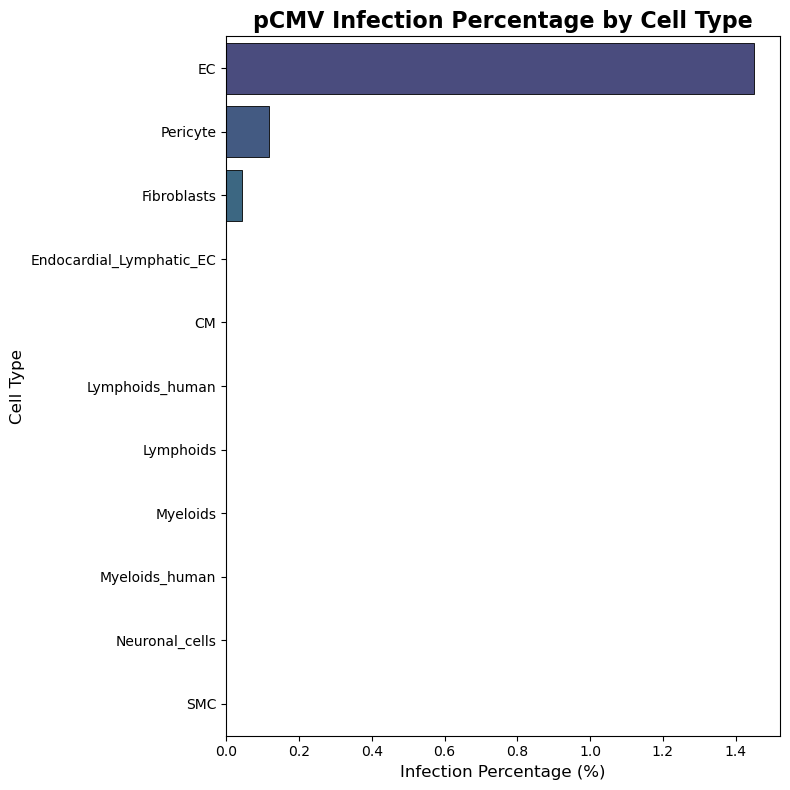

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# --- Step 1: Create or load your DataFrame ---
data = {
    'Cell Type': [
        'EC', 'Pericyte', 'Fibroblasts', 'Endocardial_Lymphatic_EC',
        'CM', 'Lymphoids_human', 'Lymphoids', 'Myeloids', 'Myeloids_human',
        'Neuronal_cells', 'SMC'
    ],
    'Infection Percentage': [
        1.449275, 0.116414, 0.044316, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    ]
}
percentage_df = pd.DataFrame(data)

# Sort the DataFrame (Crucial for consistent coloring)
percentage_df = percentage_df.sort_values(by='Infection Percentage', ascending=False)


# --- Step 2: Generate Custom Color Palette ---
# Get the number of bars/cell types
num_bars = len(percentage_df)

# Create a list of colors from the viridis colormap,
# ranging from 20% (0.2) to 90% (0.9) intensity, as requested.
# These colors will be assigned sequentially based on the sorted DataFrame order.
custom_colors = cm.get_cmap("viridis")(np.linspace(0.2, 0.9, num_bars))


# --- Step 3: Create the bar plot ---
plt.figure(figsize=(8, 8))

# Pass the custom list of colors to the palette argument
ax = sns.barplot(
    x='Infection Percentage',
    y='Cell Type',
    data=percentage_df,
    palette=custom_colors
)


# --- Step 4: Add Black Edge and Line Width (using ax.patches) ---
# ax.patches holds all the rectangular bar objects
for rect in ax.patches:
    # rect.set_color is not needed since the palette handles the fill color
    rect.set_edgecolor("black")
    rect.set_linewidth(0.6)


# --- Step 5: Customize the plot ---
plt.title('pCMV Infection Percentage by Cell Type', fontsize=16, fontweight='bold')
plt.xlabel('Infection Percentage (%)', fontsize=12)
plt.ylabel('Cell Type', fontsize=12)

plt.tight_layout()


# --- Step 6: Display and save the plot ---
plt.savefig('infection_percentage_barplot_horizontal_custom_color.png', dpi=300)

plt.show()

/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_52880/1723099683.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_colors = cm.get_cmap("viridis")(np.linspace(0.2, 0.9, num_bars))
/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_52880/1723099683.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_52880/1723099683.py:36: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(


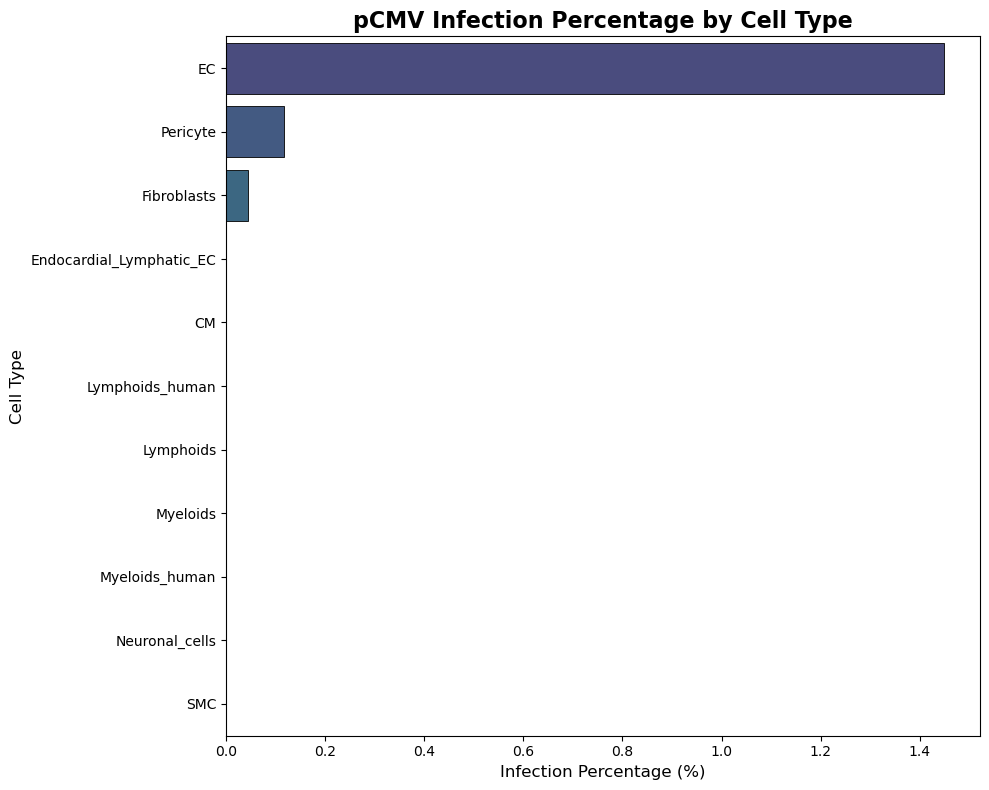

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# --- Step 1: Create or load your DataFrame ---
data = {
    'Cell Type': [
        'EC', 'Pericyte', 'Fibroblasts', 'Endocardial_Lymphatic_EC',
        'CM', 'Lymphoids_human', 'Lymphoids', 'Myeloids', 'Myeloids_human',
        'Neuronal_cells', 'SMC'
    ],
    'Infection Percentage': [
        1.449275, 0.116414, 0.044316, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    ]
}
percentage_df = pd.DataFrame(data)

# Sort the DataFrame (Crucial for consistent coloring)
percentage_df = percentage_df.sort_values(by='Infection Percentage', ascending=False)


# --- Step 2: Generate Custom Color Palette ---
num_bars = len(percentage_df)

# Create a list of colors from the viridis colormap
custom_colors = cm.get_cmap("viridis")(np.linspace(0.2, 0.9, num_bars))


# --- Step 3: Create the bar plot ---
# Set the figure size with width=10. A 10x8 aspect ratio is often good for bar charts.
plt.figure(figsize=(10, 8))

# Generate the bar plot
ax = sns.barplot(
    x='Infection Percentage',
    y='Cell Type',
    data=percentage_df,
    palette=custom_colors
)


# --- Step 4: Add Black Edge and Line Width ---
for rect in ax.patches:
    rect.set_edgecolor("black")
    rect.set_linewidth(0.6)


# --- Step 5: Customize the plot ---
plt.title('pCMV Infection Percentage by Cell Type', fontsize=16, fontweight='bold')
plt.xlabel('Infection Percentage (%)', fontsize=12)
plt.ylabel('Cell Type', fontsize=12)

plt.tight_layout()


# --- Step 6: Save the plot as PDF with width=10 ---
# Use the .pdf extension and explicitly set the dpi for high quality
plt.savefig('infection_percentage_barplot_horizontal.pdf', 
            dpi=300, 
            bbox_inches='tight')

# Display the plot
plt.show()